In [13]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import open_image
from scipy.interpolate import griddata
import os

In [17]:
def load_m3_dataset(rfl_hdr_path, loc_hdr_path):
    
    rfl_img = open_image(rfl_hdr_path)
    cube = rfl_img.load()
    
    # 🔥 FIX: remove singleton dimension
    if cube.ndim == 4:
        cube = np.squeeze(cube)
    
    wavelengths = np.array(rfl_img.bands.centers)
    
    loc_img = open_image(loc_hdr_path)
    loc = loc_img.load()
    
    if loc.ndim == 4:
        loc = np.squeeze(loc)
    
    lat = loc[:, :, 1]
    lon = loc[:, :, 0]
    
    return cube, lat, lon, wavelengths

def validate(cube, lat, lon, name):
    print(f"\n{name}")
    print("Shape:", cube.shape)
    print("Lat range:", np.nanmin(lat), np.nanmax(lat))
    print("Lon range:", np.nanmin(lon), np.nanmax(lon))

def plot_rgb(cube, wavelengths, title):
    
    def band(w):
        return np.argmin(np.abs(wavelengths - w))
    
    r = cube[:, :, band(750)]
    g = cube[:, :, band(550)]
    b = cube[:, :, band(450)]
    
    rgb = np.stack([r, g, b], axis=-1)
    
    # Remove any extra dims just in case
    rgb = np.squeeze(rgb)
    
    # Normalize safely
    rgb_min = np.nanpercentile(rgb, 2)
    rgb_max = np.nanpercentile(rgb, 98)
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)
    rgb = np.clip(rgb, 0, 1)
    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_spectrum(cube, wavelengths, x=200, y=200):
    
    spec = cube[y, x, :]
    
    plt.figure()
    plt.plot(wavelengths, spec)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance")
    plt.title(f"Spectrum at ({x},{y})")
    plt.grid()
    plt.show()

def flatten(lat, lon, band):
    return lat.flatten(), lon.flatten(), band.flatten()

def create_grid(lat1, lon1, lat2, lon2, res=0.01):
    
    lat_min = min(np.nanmin(lat1), np.nanmin(lat2))
    lat_max = max(np.nanmax(lat1), np.nanmax(lat2))
    lon_min = min(np.nanmin(lon1), np.nanmin(lon2))
    lon_max = max(np.nanmax(lon1), np.nanmax(lon2))
    
    grid_lon, grid_lat = np.meshgrid(
        np.arange(lon_min, lon_max, res),
        np.arange(lat_min, lat_max, res)
    )
    
    return grid_lat, grid_lon


def interpolate(lat, lon, values, grid_lat, grid_lon):
    
    points = np.column_stack((lat, lon))
    
    return griddata(points, values, (grid_lat, grid_lon), method='linear')

def mosaic(cube1, lat1, lon1, cube2, lat2, lon2, wavelengths):
    
    band_idx = np.argmin(np.abs(wavelengths - 1000))
    
    band1 = cube1[:, :, band_idx]
    band2 = cube2[:, :, band_idx]
    
    lat1f, lon1f, val1 = flatten(lat1, lon1, band1)
    lat2f, lon2f, val2 = flatten(lat2, lon2, band2)
    
    grid_lat, grid_lon = create_grid(lat1, lon1, lat2, lon2)
    
    g1 = interpolate(lat1f, lon1f, val1, grid_lat, grid_lon)
    g2 = interpolate(lat2f, lon2f, val2, grid_lat, grid_lon)
    
    mosaic = np.nanmean(np.stack([g1, g2]), axis=0)
    
    return mosaic, grid_lat, grid_lon

def plot_mosaic(mosaic, grid_lat, grid_lon):
    
    plt.figure(figsize=(8,6))
    plt.pcolormesh(grid_lon, grid_lat, mosaic, shading='auto')
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title("M³ Mosaic (~1000 nm)")
    plt.colorbar(label="Reflectance")
    plt.show()

def plot_band(mosaic_cube, wavelengths, grid_lat, grid_lon, target):
    
    idx = np.argmin(np.abs(wavelengths - target))
    
    band = mosaic_cube[:, :, idx]
    
    plt.figure(figsize=(8,6))
    plt.pcolormesh(grid_lon, grid_lat, band, shading='auto')
    plt.colorbar(label="Reflectance")
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(f"Mosaic at {wavelengths[idx]:.1f} nm")
    plt.show()

def normalize_longitude(lon):
    lon = lon.copy()
    lon[lon > 180] -= 360
    return lon


def clean_invalid(lat, lon, values):
    mask = (
        np.isfinite(lat) &
        np.isfinite(lon) &
        np.isfinite(values)
    )
    return lat[mask], lon[mask], values[mask]


def create_grid(lat1, lon1, lat2, lon2, res=0.01):
    
    lat_min = min(np.nanmin(lat1), np.nanmin(lat2))
    lat_max = max(np.nanmax(lat1), np.nanmax(lat2))
    lon_min = min(np.nanmin(lon1), np.nanmin(lon2))
    lon_max = max(np.nanmax(lon1), np.nanmax(lon2))
    
    grid_lon, grid_lat = np.meshgrid(
        np.arange(lon_min, lon_max, res),
        np.arange(lat_min, lat_max, res)
    )
    
    return grid_lat, grid_lon

def hyperspectral_mosaic(cube1, lat1, lon1,
                         cube2, lat2, lon2,
                         wavelengths,
                         res=0.01):
    
    # Normalize longitude
    lon1 = normalize_longitude(lon1)
    lon2 = normalize_longitude(lon2)
    
    # Create grid
    grid_lat, grid_lon = create_grid(lat1, lon1, lat2, lon2, res)
    
    n_bands = cube1.shape[2]
    mosaic_cube = np.zeros((*grid_lat.shape, n_bands))
    
    print("Creating mosaic...")
    
    for b in range(n_bands):
        print(f"Band {b+1}/{n_bands}")
        
        band1 = cube1[:, :, b]
        band2 = cube2[:, :, b]
        
        # Flatten
        lat1f = lat1.flatten()
        lon1f = lon1.flatten()
        val1 = band1.flatten()
        
        lat2f = lat2.flatten()
        lon2f = lon2.flatten()
        val2 = band2.flatten()
        
        # Clean NaNs
        lat1f, lon1f, val1 = clean_invalid(lat1f, lon1f, val1)
        lat2f, lon2f, val2 = clean_invalid(lat2f, lon2f, val2)
        
        # Interpolate
        grid1 = griddata((lat1f, lon1f), val1,
                         (grid_lat, grid_lon),
                         method='linear')
        
        grid2 = griddata((lat2f, lon2f), val2,
                         (grid_lat, grid_lon),
                         method='linear')
        
        # Merge
        mosaic_band = np.nanmean(np.stack([grid1, grid2]), axis=0)
        
        mosaic_cube[:, :, b] = mosaic_band
    
    return mosaic_cube, grid_lat, grid_lon

In [19]:
def normalize_longitude(lon):
    lon = lon.copy()
    lon[lon > 180] -= 360
    return lon

lon1 = normalize_longitude(lon1)
lon2 = normalize_longitude(lon2)

band_idx = np.argmin(np.abs(wavelengths - 1000))

band1 = cube1[:, :, band_idx]
band2 = cube2[:, :, band_idx]

def flatten_clean(lat, lon, values):
    latf = lat.flatten()
    lonf = lon.flatten()
    valf = values.flatten()
    
    mask = np.isfinite(latf) & np.isfinite(lonf) & np.isfinite(valf)
    
    return latf[mask], lonf[mask], valf[mask]

lat1f, lon1f, val1 = flatten_clean(lat1, lon1, band1)
lat2f, lon2f, val2 = flatten_clean(lat2, lon2, band2)


In [20]:
res = 0.05  # IMPORTANT: start coarse

lat_min = min(lat1f.min(), lat2f.min())
lat_max = max(lat1f.max(), lat2f.max())
lon_min = min(lon1f.min(), lon2f.min())
lon_max = max(lon1f.max(), lon2f.max())

grid_lon, grid_lat = np.meshgrid(
    np.arange(lon_min, lon_max, res),
    np.arange(lat_min, lat_max, res)
)

print("Interpolating D1...")
grid1 = griddata((lat1f, lon1f), val1,
                 (grid_lat, grid_lon),
                 method='linear')

print("Interpolating D2...")
grid2 = griddata((lat2f, lon2f), val2,
                 (grid_lat, grid_lon),
                 method='linear')

Interpolating D1...
Interpolating D2...


C:\Users\PhD24-2\AppData\Local\Temp\ipykernel_24872\3572223762.py:1: RuntimeWarning: Mean of empty slice
  mosaic_band = np.nanmean(np.stack([grid1, grid2]), axis=0)


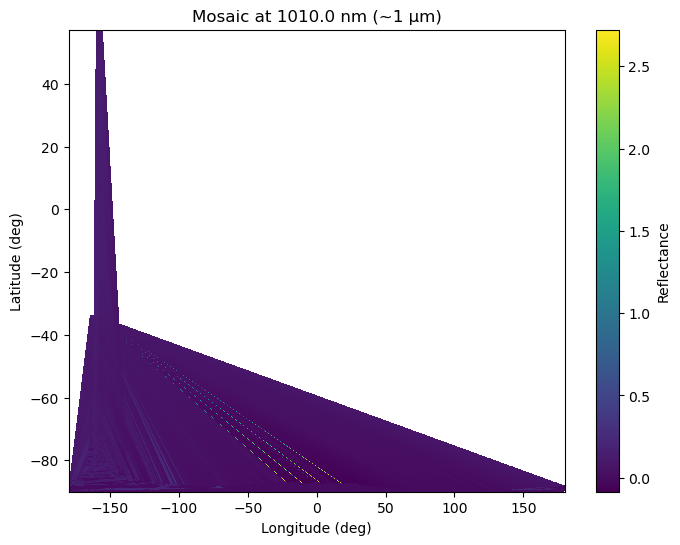

In [21]:
mosaic_band = np.nanmean(np.stack([grid1, grid2]), axis=0)

plt.figure(figsize=(8,6))

plt.pcolormesh(grid_lon, grid_lat, mosaic_band, shading='auto')
plt.colorbar(label="Reflectance")

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Mosaic at {wavelengths[band_idx]:.1f} nm (~1 µm)")

plt.show()

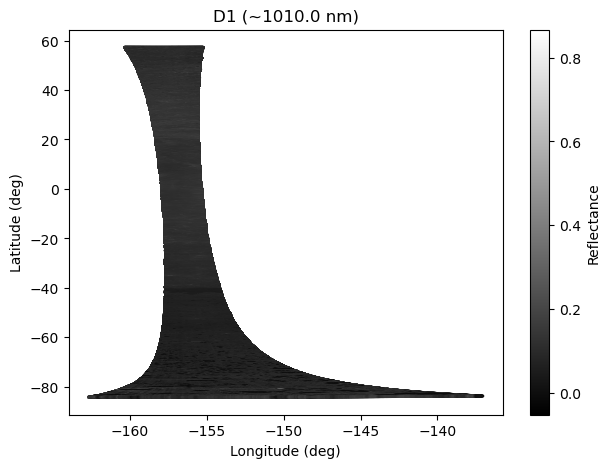

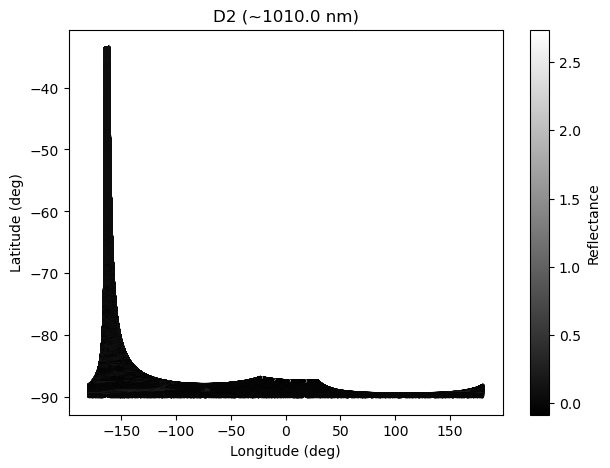

In [24]:
band_idx = np.argmin(np.abs(wavelengths - 1000))

band1 = cube1[:, :, band_idx]
band2 = cube2[:, :, band_idx]

def normalize_longitude(lon):
    lon = lon.copy()
    lon[lon > 180] -= 360
    return lon

lon1 = normalize_longitude(lon1)
lon2 = normalize_longitude(lon2)

plt.figure(figsize=(7,5))

plt.scatter(lon1, lat1,
            c=band1,
            s=1,
            cmap='gray')   # grayscale = less misleading

plt.colorbar(label="Reflectance")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"D1 (~{wavelengths[band_idx]:.1f} nm)")

plt.show()

plt.figure(figsize=(7,5))

plt.scatter(lon2, lat2,
            c=band2,
            s=1,
            cmap='gray')

plt.colorbar(label="Reflectance")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"D2 (~{wavelengths[band_idx]:.1f} nm)")

plt.show()

In [26]:
print("D1 min/max:", np.nanmin(cube1), np.nanmax(cube1))
print("D2 min/max:", np.nanmin(cube2), np.nanmax(cube2))
print("Band index:", band_idx)
print("Wavelength:", wavelengths[band_idx])

D1 min/max: -999.0 1.7326804
D2 min/max: -999.0 4.5940046
Band index: 21
Wavelength: 1009.95


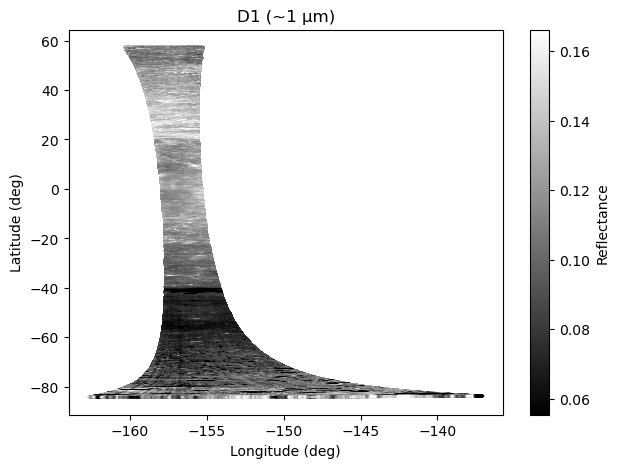

In [28]:
def refine_cube(cube):
    
    cube = cube.copy()
    
    # remove fill
    cube[cube == -999] = np.nan
    
    # remove negatives
    cube[cube < 0] = np.nan
    
    # soft upper clipping (not harsh)
    cube[cube > 2.0] = np.nan
    
    return cube

cube1 = refine_cube(cube1)
cube2 = refine_cube(cube2)

band_idx = np.argmin(np.abs(wavelengths - 1000))

band1 = cube1[:, :, band_idx]
band2 = cube2[:, :, band_idx]

plt.figure(figsize=(7,5))

vmin = np.nanpercentile(band1, 2)
vmax = np.nanpercentile(band1, 98)

plt.scatter(lon1.flatten(), lat1.flatten(),
            c=band1.flatten(),
            s=1,
            cmap='gray',
            vmin=vmin,
            vmax=vmax)

plt.colorbar(label="Reflectance")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("D1 (~1 µm)")

plt.show()


D1
Shape: (28770, 304, 85)
Lat range: -84.20518 57.29629
Lon range: 197.29729 222.96153

D2
Shape: (12066, 304, 85)
Lat range: -89.998764 -33.495396
Lon range: 0.00075851235 359.99902


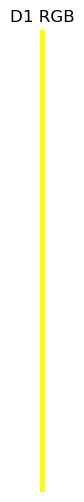

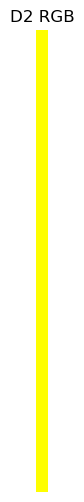

ValueError: x and y must have same first dimension, but have shapes (85,) and (1, 1, 85)

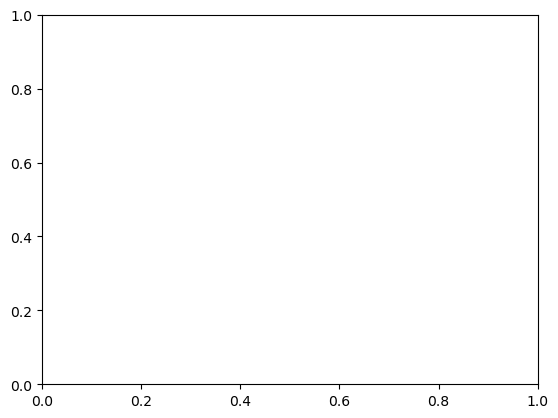

In [23]:
# Load datasets
base_path = r"C:\Users\PhD24-2\Downloads\M3d1d2"
hdr1 = os.path.join(base_path, "M3D1_V01_RFL.HDR")
img1 = os.path.join(base_path, "M3D1_V01_RFL.IMG")
loc1 = os.path.join(base_path, "M3D1_V01_LOC.HDR")

hdr2 = os.path.join(base_path, "M3D2_V01_RFL.HDR")
img2 = os.path.join(base_path, "M3D2_V01_RFL.IMG")
loc2 = os.path.join(base_path, "M3D2_V01_LOC.HDR")

cube1, lat1, lon1, wavelengths = load_m3_dataset(hdr1, loc1)

cube2, lat2, lon2, _ = load_m3_dataset(hdr2, loc2)

# Validate
validate(cube1, lat1, lon1, "D1")
validate(cube2, lat2, lon2, "D2")

# Visual checks
plot_rgb(cube1, wavelengths, "D1 RGB")
plot_rgb(cube2, wavelengths, "D2 RGB")

plot_spectrum(cube1, wavelengths)

# Mosaic
mosaic_img, grid_lat, grid_lon = mosaic(
    cube1, lat1, lon1,
    cube2, lat2, lon2,
    wavelengths
)

plot_mosaic(mosaic_img, grid_lat, grid_lon)

In [18]:
plot_band(mosaic_cube, wavelengths, grid_lat, grid_lon, 3000)

NameError: name 'mosaic_cube' is not defined